# Week 3-2 
## Data types, functions cont. 
- Lists are mutable, any data type (can easily change aspects of the list; add, remove, change.)
- Tuples are immutable, also any data type (cannot change aspects of list without replacing tuple.)
- Files are a way to store information. 

In [1]:
l = [1, 2, 3, 4, 5]
l.append(6)
print(l)

[1, 2, 3, 4, 5, 6]


In [2]:
l = [1, 2, 3, 4, 5]
l.insert(0, 0)
print(l)

[0, 1, 2, 3, 4, 5]


In [4]:
l = [1, 2, 3, 4, 5]
l.extend([6,7])
print(l)

[1, 2, 3, 4, 5, 6, 7]


In [ ]:
l.remove(1)
print(l)


[2, 3, 4, 5, 6, 7]


In [ ]:
l.pop(1)

#if pop(?)==?:

3

In [8]:
t1 = 1, 2, 3
t2 = (2, 3)
t3 = (2, "test")

print(type(t1), type(t2), type(t3))

<class 'tuple'> <class 'tuple'> <class 'tuple'>


In [ ]:
f = open('demo.txt')
#the type(f) will return _io.TextIOWrapper
#types: rt, wt, at, rb, wb, ab (different permissions)

## Formatting strings
- %, string.format() and f-strings

## Lambda functions in Python
- If list comprehension is another way to create a list, then lambda functions are another way to create a function
- We define functions as: 
`def test(x): x % 2 ==0`
- Then lambda would be: 
`lambda x:x%2 == 0`
    - a lambda function is just a function without a name. 
    - it can take multiple arguments, e.g. `lambda x,y:x+y`
    - a function can be called by its name, but with a lambda function you have to call the whole line. It is a one-time use
- We can use it to sort.

In [ ]:
def sort_words(sen):
    l = sen.split()
    return sorted(l, key=str.lower) #keeps the sentence completely original but treats everything like lowercase

sen = "Look at this! photograph"
print(sort_words(sen))

['at', 'Look', 'photograph', 'this!']


In [18]:
#can sort by sum of inner lists
n = [[1, 6], [2, 1], [3, 2]]
n.sort(key = lambda x: sum(x)) #sort by sum of inner list
print(n)

[[2, 1], [3, 2], [1, 6]]


- See week3-practice2.ipynb, Q1 for lambda function practice. 

## Dictionaries
- If we want to store + use grade infromation for students. 
    - potentially: use a list. info stored across many lists at the same index, e.g: 
    `name = [alice, bob, charlie]; grade = [b+, c-, a+]`
    - Indirectly need to look up
    - Not effective and not efficient...
- Introduce dict as another data structure that maps a key to a value 
    - a list: index 0, 1, 2, 3, 4.... with corresponding elements 
    - a dict: index key1, key2, key3... with corresponding values
- stores pairs of data as entries
    - key: may be str, int, bool, tuple, but NOT a list or dict (must be immutable)
    - value: can be anything, including lists and dicts (can be any object)
- use curly brackets `{}` to create dictionary
- very easy to change dict (e.g. to update someone's grade); or add an entry (e.g. new student)

In [ ]:
grades = {'alice' : 'B+',
          'bob' : 'A',
          'charlie' : 'C'}
print(grades)

grades['alice'] = 'A'
print(grades)

grades['dallas'] = 'D'
print(grades)

del(grades['alice'])
print(grades)
print(grades['bob'])

#use in to check the existence of a key, but not the value. significantly faster than list
print('alice' in grades)
print('bob' in grades)

# get all the keys, returns a tuple of all keys
grades.keys()

# get all values, returns a tuple of all values
grades.values()

# get all keys + values (items), returns tuple
grades.items()

{'alice': 'B+', 'bob': 'A', 'charlie': 'C'}
{'alice': 'A', 'bob': 'A', 'charlie': 'C'}
{'alice': 'A', 'bob': 'A', 'charlie': 'C', 'dallas': 'D'}
{'bob': 'A', 'charlie': 'C', 'dallas': 'D'}
A
False
True


dict_items([('bob', 'A'), ('charlie', 'C'), ('dallas', 'D')])

- see week3-practice2.ipynb Q2/Q3 for more practice.
- we can use dictionaries as a word counter
    - assign a word as a key and for loop through a list, for example. Then, can add 1 to counter, or keep going. Find the highest value in the dictionary and find the key attached to it. 
- memoization - if we want to write the Fibonacci sequence, we want to add prev numbers together. 

In [ ]:
def naive_fibo(n):
    if n < 0: 
        raise ValueError('negative fibonacci number...')
    if n == 0: 
        return 0 
    elif n ==1: 
        return 1 
    else: 
        return naive_fibo(n-1) + naive_fibo(n -2)
    
for i in range(8, 13):
    print(naive_fibo(i))

21
34
55
89
144


In [21]:
#30 took 0.6s; 50 took at least 7 mins!!
naive_fibo(30)

832040

- what ends up happening is that the function ends up repeating many of the same functions, which very quickly starts taking more time. 
- instead, we can define a dictionary to store numbers for future uses. 

In [29]:
import time

known = {0:0, 1:1}
def fibo(n): 
    if n in known: 
        return known[n]
    else: 
        f = fibo(n-1) + fibo(n-2)
        known[n] = f 
        return(f)

i = 10000
start_time = time.time()
print(f"fibo to {i} iterations: {fibo(i)})") 
print(time.time() - start_time)

RecursionError: maximum recursion depth exceeded

## Files
### pickle module 
- used to serialize/deserialize python object
- for e.g. `t1 = [1, 'two', 3.0]`. using pickle.dumps will turn this list into a binary string that represents that objects; can be used to convert back into a python object (using pickle.loads)
- note that this stores a representation of the value, rather than the variable itself. so it is equivalent, but not identical!
### os module 
- os.getcwd() get current working directory
- os.listdir() lists content of directory 
- etc. helps us with file manipulation. 

# Week 4-1
## Object Oriented Programming (OOP)
- objects are everywhere: primitives (1, 2, 0, True, None) and lists/strings/tuples/dict
- Each is an object instance and each object has some internal data representation wth a set of procedures (functions/methods) for itneraction w/ the object
- objects are data abstration that captures: 
    - an internal representation: through data attributes
    - an itnerface for itneracting with objects thru methods (procedures, functions) and defines behaviors but hides implementations 
- an object is an instance of a type. 507 is an instance of an `int`, etc.
### Creating/using a class
Sometimes we use a collection of variables to represent a specific object, e.g. we used a list of a list to represent a matrix; representing state of a board game of players/piece/positions; representing a statistical model 
- Creating vs using an instance of a class
    - creating the class: 
        - defining class name, data attributes, procedural attributes
    - using the class: 
        - creat new instances of the class; do operations on the instance 
        - create list and try to index OR find length, etc...
- defining a class is similar to defining a function
- creating a new object

In [ ]:
class Point(): 
    '''represents a 2-d point (x,y)'''
    #adding attributes (1: data attribute)
    def __init__(self, xval, yval):
        self.x = xval
        self.y = yval

    def __str__(self): 
        return f"Point({self.x, self.y})"
    
    def distance(self, other_point):
        x_diff_square = (self.x - other_point.x) ** 2
        y_diff_square = (self.y - other_point.y) ** 2
        return (x_diff_square + y_diff_square) ** 0.5

print(Point) #it will recognize that this is a custom data type;/ instantiation. 
p1 = Point(1.0, 2.5)
p2 = Point(0.4, 1.2)
print(p1.distance(p2))
print(p1.x, p1.y)
print(type(p1))

<class '__main__.Point'>
1.4317821063276355
1.0 2.5
<class '__main__.Point'>


adding attributes: data attribute
- we can add data atrributes directly inside the class but outside of any method, e.g. called class attributes
- or use `__init__()` method; aka double underscore/dunder method
    - special method to initialize some data attributes or perform the operation. defines how to create an instance of the class
    - what is self? self is a parameter to refer to an instance of the class WIHTOUT creating one. always going to be the first parameter of any given method.
- `__str__()`; defines string representation of object. should return a string when print(object), str(object) or f"{object}"
- see week 4 practice 1 for more practice. 
- objects are mutable
- can nest objects
### getters and setters
- getters and setters should be used outside of class to access data attributes


In [3]:
class Point(): 
    '''represents a 2-d point (x,y)'''
    #adding attributes (1: data attribute)
    def __init__(self, xval, yval):
        self.x = xval
        self.y = yval

    def get_x(self): 
        return self.x
    
    def set_x(self, value): 
        if not isinstance(value, (int, float)):
            raise ValueError ("x must be a number")
        self.x = value

    def get_y(self): 
        return self.y
    
    def set_y(self, value): 
        if not isinstance(value, (int, float)):
            raise ValueError ("x must be a number")
        self.y = value

    def __str__(self): 
        return f"Point({self.x, self.y})"
    
    def distance(self, other_point):
        x_diff_square = (self.x - other_point.x) ** 2
        y_diff_square = (self.y - other_point.y) ** 2
        return (x_diff_square + y_diff_square) ** 0.5

print(Point) #it will recognize that this is a custom data type;/ instantiation. 


p1 = Point(3, 4)
print(p1.get_x(), p1.get_y())
p1.set_x(5)
p1.set_y(6)
print(p1.get_x(), p1.get_y())

#print(p1.distance(p2))
#print(p1.x, p1.y)
#print(type(p1))

<class '__main__.Point'>
3 4
5 6


## inheritance hierarchies
- inheritance allows us to creat new classes from old ones; child classes allow us to inherit all data and behaviors of the parent class. allows us to add more info/data, add more behavior and override previous hehavior. 

In [11]:
#to create a child hierarchy:
class Area(Point):
    print("test")
    def __init__(self):
        super().__init__(Point)
        print("this is a test")

test


# Week 4-2
## Recap 
Class is a programmer-defined type; internal representation or interface.
One more thing for OOP on `__init__()`:
- method to initalize some data attributes 
- for child classes, can use `super().__init__(parent class)` to initalize all parent class attributes correctly
## Iteration and iterable 
- Iterable = object capable of returning members one at a time (lists, sequence types (string, tuple), and stuff like dicts, files, etc.) 
    - `__iter__()` method; object can be looped over.
- iterator = object that represents a 'data stream'. Supports method `__next__()` and raises "StopIteration" error when no more elements. just think of it as supporting these methods.
    - a list is NOT an iterator according to this definition.
    - can help save memory for a huge dataset



In [ ]:
num = [1,2,3]
#print(next(num)) #<- returns an error
titer = iter(num) #but it does support iter function which DOES support the next function
next(titer)

1

In [16]:
next(titer)

2

### Iterator in for loop
### Creating an iterator -- a dummy class
- Without the iter or next methods in a class, it will NOT have the ability to iterate

In [4]:
class Squares():
    def __init__(self):
        self.n = 0
    def __next__(self):
        (self.n, k) = (self.n+1, self.n)
        return(k*k)
    def __iter__(self):
        return(self)

s = Squares()
[next(s) for _ in range(20)]

#but this will return an error
#for x in s: 
#    print(x)

[0,
 1,
 4,
 9,
 16,
 25,
 36,
 49,
 64,
 81,
 100,
 121,
 144,
 169,
 196,
 225,
 256,
 289,
 324,
 361]

## Generator 
It's really annoying to have to create an iterable every time I need to do something. It's easier to define a simple function

In [5]:
def square(k):
    return (k*k)

[square(x) for x in range(17) if x%2==0]

[0, 4, 16, 36, 64, 100, 144, 196, 256]

In [ ]:
s = Squares()
[x**2 for x in s] #infintie loop

KeyboardInterrupt: 

In [7]:
sqgen = (x**2 for x in s)
sqgen

<generator object <genexpr> at 0x000002CBC574E400>

-Generators will yield, rather than return. 


In [8]:
def harmonic(n):
    return(sum([1/k for k in range(1,n+1)]))
harmonic(10)

2.9289682539682538

In [10]:
def harmonic():
    (h,n) = (0,1)
    while True:
        (h,n) = (h+1/n, n+1)
        yield h
h = harmonic()
[next(h) for _ in range(10)]

[1.0,
 1.5,
 1.8333333333333333,
 2.083333333333333,
 2.283333333333333,
 2.4499999999999997,
 2.5928571428571425,
 2.7178571428571425,
 2.8289682539682537,
 2.9289682539682538]

** see week4_2practice for iterator class + generator practice.
## Exceptions and Assertions
- lists of errors; index, name, value, type

# Week 5-1
Algorithm thinking
Recap: 4
- Iterator is an object that represents data strem; supports method `__next__():` (returns next element; raises `StopIteration` when no more elements left)
- Generators: generates an iterable from non-iterable (?)
## Program efficiency
- besides correctness (the program provides the correct/expected output) we also care about efficiency, since data sets can be very large
- we care about: 
    - time efficiency (how fast)
    - space efficiency (how much memory)
    - tradeoff between them e.g. fibonacci recursive vs fibonacci with memorization
    - focus on algorithms rather than implementations (while, for)
### Timing programs and counting operations
- Measure with a timer OR count the operations

In [1]:
def my_fun (n):
    total = 0
    for i in range(n): 
        total += i
    return total 

In [2]:
import time
def measure_time(func, n):
    start = time.time()
    func(n)
    end=time.time()
    return end - start

input_sizes = [10,100,1000,10000,10000000]
for n in input_sizes: 
    execution_time = measure_time(my_fun, n)
    print(f"n= {n:<7}, Time = {execution_time:.6f} seconds")

n= 10     , Time = 0.000010 seconds
n= 100    , Time = 0.000021 seconds
n= 1000   , Time = 0.000109 seconds
n= 10000  , Time = 0.001149 seconds
n= 10000000, Time = 1.429069 seconds


- Timer in practice: `time.perf_counter()`

In [4]:
def perf_measure(func, n):
    start = time.perf_counter()
    func(n)
    end = time.perf_counter()
    return end-start

input_sizes = [10,100,1000,10000,10000000]
for n in input_sizes: 
    execution_time = measure_time(my_fun, n)
    print(f"n= {n:<7}, Time = {execution_time:.6f} seconds")

n= 10     , Time = 0.000010 seconds
n= 100    , Time = 0.000017 seconds
n= 1000   , Time = 0.000112 seconds
n= 10000  , Time = 0.001242 seconds
n= 10000000, Time = 1.310964 seconds


### Counting operations
- Count operations assuming all these steps take constant time (mathematical operations, comparisons, assignments and accessing objects in memory (indexing))

In [5]:
#count number of operations in the following...
def array_sum(arr):
    total = 0 # 1 operation 
    for i in range(len(arr)):
        total += arr[i] #3 operations per iteration
    return total #1 operation

#3n + 2 

In [ ]:
def print_all_pairs(arr):
    n = len(arr) #1 operation
    for i in range(n):
        for j in range(n):
            print(f"{arr[i], arr[j]}") #2 operations
    
print_all_pairs([1,2,3])
#2n^2 + 1

(1, 1)
(1, 2)
(1, 3)
(2, 1)
(2, 2)
(2, 3)
(3, 1)
(3, 2)
(3, 3)


In [9]:
def fibonacci(n): 
    if n <= 1: 
        return 1
    return fibonacci(n-1) + fibonacci(n-2) 

perf_measure(fibonacci, 1)

3.1999998100218363e-06

## Big O and $\Theta$
- asymptotic growth: order of growth; evaluate programs by timer + counter, but also "abstract notion of order of growth". 
    - put a "bound" (lower/higher) on the growth
    - do not need to be precise: "order of" not "exact" growth
    - focus on the terms that grows rapidly (e.g. ignore additive/multiplicative)

- order of growth or O/$\theta$ notation
    - big O notation charactersizes na upper bound on the asymptotic behavior of a function; the function grows not faster than a certain rate. 

    - $$f(n)=O(g(n)) \text{ means there exist constants } c_0, n_0 \text{ for which } c_0g(n) \geq f(n); n>n_0 $$
        - $f(n) = 3n^2 + 5$
            - $c_0g(n)=4n^3$
            - $c_0g(n)=2n^3$
            - $c_0g(n) = 1*2^n$

- lower bound: $\Omega$
    -  $$f(n)=\Omega(g(n)) \text{ means there exist constants } c_0, n_0 \text{ for which } f(n) \geq c_0g(n); n>n_0 $$
    - $f(n) = 3n^2 + 5$
        - $c_0g(n)=2n^2$
        - $c_0g(n)=2n$
        - $c_0g(n) = 5$

- tight bound $\Theta$
    -  $$f(n)=\Theta(g(n)) \text{ means there exist constants } c_0, n_0 \text{ for which } c_2g(n) \geq f(n) \geq c_1g(n); n>n_0 $$
    - squeeze theorem of above two
       - $f(n) = 4n^2$

- you should know this for exam!

### $\Theta(x)$ complexity cases
- O(1) and O(log(n)) denotes constant or logarithmic running time
- O(n) = linear
- O(n log(n)) = log-linear running time
everything below is bad and should be avoided
- O(n^c) = polynomial 
- O(c^n) = exponential 
- O(n!) = factorial

# Week 5-2
# Starting Part 2 of class - Numerical Computer + Data Visualization
numpy, scipy, matplotlib, scikit-learn, Seaborn,....

numpy is especially good for numerical computing; built in optimized vector computation

In [3]:
import numpy as np

## Numpy
types of data in numy
- boolean (bool)
- integer (int32, int64)
- unsigned int (uint)
- floating point (float32, float64)
- complex (complex)

In [7]:
x = np.float64(3.1415)
x

y = np.float32(3.1415)
y

x==y
x==np.float64(y)

np.False_

N-dimensional arrays: np.ndarray. doesnt' matter what type (list or tuple) as long as the data are all the sample type. 

In [ ]:
x = np.array([[1,2,3,4,5,6],[7,8,9,10,11,12]], dtype = int)
np.arange(0,10,2) #np.array[0,2,4,6,8]
np.linspace(0,1,5) #[0, 0.25, 0.5, 0.75, 1.]
np.eye(3) #3x3 identity matrix; np.eye(4) = 4x4
np.eye(3,5) #3x5
np.diag([1,2,3]) #diagonals with specified
x
full_like_arr = np.full_like(x, 9)
full_like_arr #same size as x with '9' in it

zeros_like_arr = np.zeros_like(x)
zeros_like_arr #same size as x with '0' in it

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]])

# Week 8-1
deep learning practice

In [14]:
from sklearn import datasets
import matplotlib.pyplot as plt
from collections import Counter

In [6]:
digits = datasets.load_digits()
len(digits.data), len(digits.data[42])

(1797, 64)

In [ ]:
digits.data[42]

array([ 0.,  0.,  0.,  0., 12.,  5.,  0.,  0.,  0.,  0.,  0.,  2., 16.,
       12.,  0.,  0.,  0.,  0.,  1., 12., 16., 11.,  0.,  0.,  0.,  2.,
       12., 16., 16., 10.,  0.,  0.,  0.,  6., 11.,  5., 15.,  6.,  0.,
        0.,  0.,  0.,  0.,  1., 16.,  9.,  0.,  0.,  0.,  0.,  0.,  2.,
       16., 11.,  0.,  0.,  0.,  0.,  0.,  3., 16.,  8.,  0.,  0.])

In [4]:
digits.images[42]

array([[ 0.,  0.,  0.,  0., 12.,  5.,  0.,  0.],
       [ 0.,  0.,  0.,  2., 16., 12.,  0.,  0.],
       [ 0.,  0.,  1., 12., 16., 11.,  0.,  0.],
       [ 0.,  2., 12., 16., 16., 10.,  0.,  0.],
       [ 0.,  6., 11.,  5., 15.,  6.,  0.,  0.],
       [ 0.,  0.,  0.,  1., 16.,  9.,  0.,  0.],
       [ 0.,  0.,  0.,  2., 16., 11.,  0.,  0.],
       [ 0.,  0.,  0.,  3., 16.,  8.,  0.,  0.]])

In [5]:
digits.target[42]

np.int64(1)

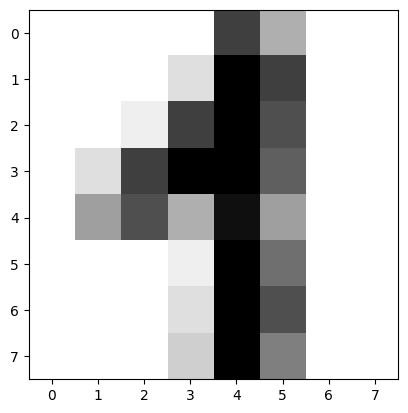

In [ ]:
plt.imshow(digits.images[42], cmap = plt.cm.gray_r)

In [15]:
Counter(digits.target)

Counter({np.int64(3): 183,
         np.int64(1): 182,
         np.int64(5): 182,
         np.int64(4): 181,
         np.int64(6): 181,
         np.int64(9): 180,
         np.int64(7): 179,
         np.int64(0): 178,
         np.int64(2): 177,
         np.int64(8): 174})

In [16]:
from sklearn import svm

In [19]:
clf = svm.SVC() #support vector classifier
clf.fit(x[:-1], y[:-1])

NameError: name 'x' is not defined

In [20]:
clf.predict(X[:-1])

NameError: name 'X' is not defined